# Mature *Vitis vinifera* Grape Berry — Host Plant Model

**Phase 1B:** Characterisation of the mature *V. vinifera* berry GEM as a preparatory step for host-pathogen simulations with *Aspergillus niger*.

---

**Author:** Joana Maia  
**Solver:** Gurobi (Academic Licence)  
**Core libraries:** COBRApy · Pandas · Seaborn · Matplotlib  
**Model:** *iMS7199* — *V. vinifera* berry mature (SBML Level $3$)

---

## 1. Environment Setup
### 1.1 Package Installation

In [1]:
# !pip install cobra
# !pip install gurobipy
# !pip install matplotlib
# !pip install pandas
# !pip install seaborn

### 1.2 Library Imports and Version Audit

In [2]:
# Standard library
import os
import html as html_lib
import warnings
warnings.filterwarnings('ignore')

# Numerical / data
import numpy as np
import pandas as pd

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# COBRApy and flux analysis tools
import cobra
from cobra.flux_analysis import (find_blocked_reactions, find_essential_genes, find_essential_reactions, flux_variability_analysis, production_envelope)
from cobra.io import read_sbml_model, write_sbml_model
import gurobipy

# Version audit
print(f'COBRApy    : {cobra.__version__}')
print(f'Gurobi     : {".".join(str(v) for v in gurobipy.gurobi.version())}')
print(f'Matplotlib : {matplotlib.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'Seaborn    : {sns.__version__}')

COBRApy    : 0.31.1
Gurobi     : 13.0.2
Matplotlib : 3.10.8
NumPy      : 2.4.4
Pandas     : 2.3.3
Seaborn    : 0.13.2


### 1.3 Global Plotting Style

In [3]:
sns.set_theme(style = 'whitegrid', context = 'notebook', font_scale = 1.1)
plt.rcParams.update({'figure.dpi'         : 120,
                     'axes.spines.top'    : False,
                     'axes.spines.right'  : False,
                     'figure.autolayout'  : True})
PALETTE_MAIN = 'BuPu_r'
PALETTE_CAT  = sns.color_palette('BuPu_r', 8) 

### 1.4 Model Loading
Load *iMS7199 berry mature* from SBML, copy into `berry_model` for analysis and store key boundary reaction IDs.

In [4]:
BERRY_MODEL_PATH = '4_iMS7199_berry_mature.xml'

if not os.path.exists(BERRY_MODEL_PATH):
    raise FileNotFoundError(f'Model file not found: {BERRY_MODEL_PATH}.')

berry_raw   = read_sbml_model(BERRY_MODEL_PATH)
berry_model = berry_raw.copy()

print(berry_model)
print(f'Unconstrained μ (berry_raw): {berry_raw.optimize().objective_value:.4f} h⁻¹')

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2747228
Academic license 2747228 - for non-commercial use only - registered to pg___@uminho.pt
         of a constant term in the left-hand side of a constraint.

Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmp6vkocenl.lp
Reading time = 0.02 seconds
: 5143 rows, 8550 columns, 35884 nonzeros
vvinif2023
Unconstrained μ (berry_raw): 0.1541 h⁻¹


In [5]:
BIOMASS_RXN_VV = 'e-Biomass_vvinif2023_berry_mature__cyto'

no3_cands = [r for r in berry_model.exchanges
              if any(k in r.id.upper() for k in ['NO3', 'NITRAT', 'NITR'])
              and r.lower_bound < 0]

NO3_RXN = no3_cands[0].id if no3_cands else None

o2_cands  = [r for r in berry_model.exchanges
              if any(k in r.id.upper() for k in ['O2', 'OXYGEN'])
              and r.lower_bound < 0]
if not o2_cands:
    o2_cands = [r for r in berry_model.exchanges
                if any('oxygen' in m.name.lower() for m in r.metabolites)
                and r.lower_bound < 0]
    
O2_RXN  = o2_cands[0].id  if o2_cands  else None
SUCROSE_RXN    = 'EX_SUCROSE_drain'

print('Global reaction ID configuration:')
print(f'    BIOMASS_RXN : {BIOMASS_RXN_VV}')
print(f'    NO₃ exchange reaction : {NO3_RXN}')
print(f'    O₂ exchange reaction  : {O2_RXN}')
print(f'    SUCROSE_RXN : {SUCROSE_RXN}')

Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.
Could not identify an external compartment by name and choosing one with the most boundary reactions. That might be complete nonsense or change suddenly. Consider renaming your compartments using `Model.compartments` to fix this.


Global reaction ID configuration:
    BIOMASS_RXN : e-Biomass_vvinif2023_berry_mature__cyto
    NO₃ exchange reaction : EX_NITRATE_drain
    O₂ exchange reaction  : EX_OXYGEN-MOLECULE_drain
    SUCROSE_RXN : EX_SUCROSE_drain


## 2. Global Characterisation
### 2.1 Initial Metabolic Summary

In [6]:
berry_model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
FE+2__extr,EX_FE+2_drain,1.5E-07,0,0.00%
NITRATE__extr,EX_NITRATE_drain,0.9763,0,0.00%
OXYGEN-MOLECULE__extr,EX_OXYGEN-MOLECULE_drain,2.44,0,0.00%
PROTON__extr,EX_PROTON_drain,5.338,0,0.00%
Pi__extr,EX_Pi_drain,0.0001165,0,0.00%
SUCROSE__extr,EX_SUCROSE_drain,1,12,100.00%
SULFATE__extr,EX_SULFATE_drain,0.03215,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
HCN__cyto,EX_HCN_drain,-2.228E-07,1,0.00%
HCO3__extr,EX_HCO3_drain,-4.714,1,43.33%


### 2.2 Objective Function

The objective reaction (`e-Biomass_vvinif2023_berry_mature__cyto`) assembles 
macromolecular components into the biomass pseudometabolite at a cost of **$53.26$ ATP per unit biomass**, reflecting the growth-associated energy requirement. This contrasts with *A. niger* (Phase 1A), where the biomass drain carried no explicit ATP cost.

**Biomass composition:**

| Component | Coefficient |
|---|---|
| Protein | $0.600$ |
| Carbohydrates | $0.300$ |
| Cell wall | $0.050$ |
| Lipids | $0.042$ |
| RNA | $0.004$ |
| DNA | $0.003$ |
| Cofactors | $0.001$ |

In [7]:
rxn = berry_model.reactions.get_by_id(BIOMASS_RXN_VV)

print(f'Objective reaction : {rxn.id}')
print(f'Name               : {rxn.name}')
print(f'Direction          : {berry_model.objective.direction}')
print(f'Bounds             : [{rxn.lower_bound}, {rxn.upper_bound}]')
print(f'Full objective     : {berry_model.objective.expression}')
print(f'Reactants          : {[m.id for m in rxn.reactants]}')
print(f'Products           : {[m.id for m in rxn.products]}')
print(f'\nEquation:        : {rxn.reaction}')

Objective reaction : e-Biomass_vvinif2023_berry_mature__cyto
Name               : e-Biomass_vvinif2023
Direction          : max
Bounds             : [0.0, 10000.0]
Full objective     : 1.0*e-Biomass_vvinif2023_berry_mature__cyto - 1.0*e-Biomass_vvinif2023_berry_mature__cyto_reverse_8949f
Reactants          : ['e-Protein__cyto', 'e-Lipids__cyto', 'e-DNA__cyto', 'e-RNA__cyto', 'e-Carbohydrates_berry_mature__cyto', 'e-Cofactor__cyto', 'e-CellWall__cyto', 'ATP__cyto', 'WATER__cyto']
Products           : ['e-Biomass__cyto', 'ADP__cyto', 'Pi__cyto']

Equation:        : 53.26 ATP__cyto + 53.26 WATER__cyto + 0.3 e-Carbohydrates_berry_mature__cyto + 0.05 e-CellWall__cyto + 0.001 e-Cofactor__cyto + 0.003 e-DNA__cyto + 0.042 e-Lipids__cyto + 0.6 e-Protein__cyto + 0.004 e-RNA__cyto --> 53.26 ADP__cyto + 53.26 Pi__cyto + e-Biomass__cyto


### 2.3 Optimal Flux Simulation via FBA

**Notes:** 
 * $μ ≈ 0.154 h⁻¹$ — mature berry tissue is post-mitotic; this represents steady-state flux through the biomass maintenance reaction, not a cell-division rate. Retained for numerical consistency with *iMS7199*.
 * Growth rate is ~$6×$ lower than *A. niger* ($0.9399 h⁻¹$) (both values reflect unconstrained default bounds and are not directly comparable without applying equivalent physiological constraints.)

In [8]:
fba_solution = berry_model.optimize()
print(f'FBA status          : {fba_solution.status}')
print(f'Objective value (μ) : {fba_solution.objective_value:.4f} h⁻¹')

FBA status          : optimal
Objective value (μ) : 0.1541 h⁻¹


### 2.4 Compartment Remapping
Remap non-standard compartment codes (C001–C010) to semantically meaningful identifiers; `C009 → 'e'` is critical for COBRApy boundary-reaction detection.

In [9]:
COMPARTMENT_MAP = {'C001': 'cytosol_plant',
                   'C002': 'pmf_plant',
                   'C003': 'chloro_plant',
                   'C004': 'mito_plant',
                   'C005': 'er_plant',
                   'C006': 'perox_plant',
                   'C007': 'golgi_plant',
                   'C008': 'vacuole_plant',
                   'C009': 'e',
                   'C010': 'lumen_plant',}

pre_remap_mu = berry_raw.optimize().objective_value

for met in berry_model.metabolites:
    if met.compartment in COMPARTMENT_MAP:
        met.compartment = COMPARTMENT_MAP[met.compartment]

berry_model.compartments = {v: v for v in COMPARTMENT_MAP.values()}

val = berry_model.optimize()
assert val.status == 'optimal', 'Model became infeasible after compartment remapping.'
assert abs(val.objective_value - pre_remap_mu) < 1e-6, \
    f'Remapping changed μ: {pre_remap_mu:.6f} →  {val.objective_value:.6f}'
print('Compartment remapping successful — model remains feasible.')
print(f'Pre-remapping μ  : {pre_remap_mu:.4f} h⁻¹')
print(f'Post-remapping μ : {val.objective_value:.4f} h⁻¹')
print()
print('Updated compartments:')
for cid, cname in sorted(berry_model.compartments.items()):
    print(f'    {cid}')

Compartment remapping successful — model remains feasible.
Pre-remapping μ  : 0.1541 h⁻¹
Post-remapping μ : 0.1541 h⁻¹

Updated compartments:
    chloro_plant
    cytosol_plant
    e
    er_plant
    golgi_plant
    lumen_plant
    mito_plant
    perox_plant
    pmf_plant
    vacuole_plant


### 2.5 Culture Medium

In [10]:
medium_df = (pd.DataFrame.from_dict(berry_model.medium, orient = 'index', columns = ['Upper bound'])
             .rename_axis('Exchange reaction')
             .sort_values('Upper bound', ascending = False))
print(f'Active exchange reactions in medium: {len(medium_df)}')
print(f'\n{"Reaction":<50} {"Uptake limit":>20} {"Secretion limit":>20}')
print('_' * 90)
for rxn_id in medium_df.index:
    rxn = berry_model.reactions.get_by_id(rxn_id)
    print(f'{rxn_id:<50} {rxn.lower_bound:>20.1f} {rxn.upper_bound:>20.1f}')

Active exchange reactions in medium: 10

Reaction                                                   Uptake limit      Secretion limit
__________________________________________________________________________________________
EX_FE+2_drain                                                  -10000.0              10000.0
EX_MG+2_drain                                                  -10000.0              10000.0
EX_WATER_drain                                                 -10000.0              10000.0
EX_OXYGEN-MOLECULE_drain                                       -10000.0              10000.0
EX_PROTON_drain                                                -10000.0              10000.0
EX_Pi_drain                                                    -10000.0              10000.0
EX_NITRATE_drain                                               -10000.0              10000.0
EX_SULFATE_drain                                               -10000.0              10000.0
EX_S-ADENOSYL-4-METHYLTHIO-2-OX

### 2.6 Biomass Function Characterisation

#### 2.6.1 Pseudometabolite Decomposition
Decompose each biomass pseudo-metabolite into its constituent real metabolites.

**Key findings:**
* **Protein** is represented via charged tRNAs.
* **Carbohydrates** include `MYRICETIN` ($0.04$) and `TARTRATE` ($0.03$) — flavonoids and organic acids are structural berry components, not just secondary metabolites. Myricetin also appeared as the most limiting exchangeable metabolite in shadow price analysis.
* **Sucrose** is simultaneously the sole carbon source and a structural carbohydrate component — creating a feedback between nutrient availability and biomass synthesis.
* **Cell wall** contains monolignols (lignin precursors targeted by *A. niger* laccases and peroxidases  during tissue invasion).
* **Cofactors** include ascorbate, glutathione, and folate derivatives — (antioxidant pool relevant to oxidative stress imposed by *A. niger* H₂O₂ secretion).

In [11]:
def decompose_pseudometabolite(model: cobra.Model, meta_id: str):
    metabolite = model.metabolites.get_by_id(meta_id)
    production_rxns = [r for r in metabolite.reactions
                       if r.metabolites[metabolite] > 0]
    if not production_rxns:
        raise ValueError(f'No production reaction found for {meta_id}')

    precursors = {}
    for rxn in production_rxns:
        for sub_met, coeff in rxn.metabolites.items():
            if coeff < 0:
                precursors[sub_met.id] = abs(coeff)
    return precursors


MACROMOLECULES = ['e-Protein__cyto', 
                  'e-Lipids__cyto', 
                  'e-DNA__cyto', 
                  'e-RNA__cyto',
                  'e-Carbohydrates_berry_mature__cyto', 
                  'e-Cofactor__cyto', 
                  'e-CellWall__cyto']

print('Detailed decomposition of biomass pseudometabolites\n' + '─'*55)
for mid in MACROMOLECULES:
    try:
        prec = decompose_pseudometabolite(berry_model, mid)
        print(f'\n{mid}')
        for k, v in sorted(prec.items(), key = lambda x: -x[1]):
            print(f'   {k:<45} {v:.6f}')
    except Exception as e:
        print(f'  Could not decompose {mid}: {e}')

Detailed decomposition of biomass pseudometabolites
───────────────────────────────────────────────────────

e-Protein__cyto
   Charged-LEU-tRNAs__cyto                       0.789443
   Charged-SER-tRNAs__cyto                       0.695559
   Charged-GLT-tRNAs__cyto                       0.511809
   Charged-GLY-tRNAs__cyto                       0.506860
   Charged-ALA-tRNAs__cyto                       0.497695
   Charged-VAL-tRNAs__cyto                       0.489080
   Charged-LYS-tRNAs__cyto                       0.463934
   Charged-ILE-tRNAs__cyto                       0.413991
   Charged-ARG-tRNAs__cyto                       0.407338
   Charged-ASP-tRNAs__cyto                       0.405191
   Charged-PRO-tRNAs__cyto                       0.379073
   Charged-THR-tRNAs__cyto                       0.363384
   Charged-ASN-tRNAs__cyto                       0.336081
   Charged-PHE-tRNAs__cyto                       0.319722
   Charged-GLN-tRNAs__cyto                       0.288282
   Ch

#### 2.6.2 Top Biomass-Contributing Metabolites
Rank the $25$ most stoichiometrically important metabolites in the biomass reaction — used to select interface metabolites for host-pathogen interaction.

In [12]:
BIO_ID = [r.id for r in berry_model.reactions 
          if 'biomass' in r.id.lower() 
          and 'drain' not in r.id.lower()][0]
target_rxn = berry_model.reactions.get_by_id(BIO_ID)

constituents = [{'ID': m.id, 'Name': m.name, 'Coefficient (mmol/gDW)': abs(c)}
                for m, c in target_rxn.metabolites.items() if c < 0]

df_const = pd.DataFrame(constituents).sort_values('Coefficient (mmol/gDW)', ascending = False)
print(df_const.to_string(index = False))

macro_weights = {m.id: abs(c)
                 for m, c in target_rxn.metabolites.items()
                 if c < 0 and m.id in MACROMOLECULES}

direct_terms = {m.id: abs(c)
                for m, c in target_rxn.metabolites.items()
                if c < 0 and m.id not in MACROMOLECULES}

print('\nMacromolecule weights (from model):')  
for k, v in sorted(macro_weights.items(), key = lambda x: -x[1]):
    print(f'  {k:<45} {v:.4f}')

print(f'\nDirect biomass terms (e.g. ATP, H₂O): {len(direct_terms)}')
for k, v in sorted(direct_terms.items(), key = lambda x: -x[1]):
    print(f'  {k:<45} {v:.4f}')


                                ID            Name  Coefficient (mmol/gDW)
                         ATP__cyto             ATP                  53.260
                       WATER__cyto             H2O                  53.260
                   e-Protein__cyto       e-Protein                   0.600
e-Carbohydrates_berry_mature__cyto e-Carbohydrates                   0.300
                  e-CellWall__cyto      e-CellWall                   0.050
                    e-Lipids__cyto        e-Lipids                   0.042
                       e-RNA__cyto           e-RNA                   0.004
                       e-DNA__cyto           e-DNA                   0.003
                  e-Cofactor__cyto      e-Cofactor                   0.001

Macromolecule weights (from model):
  e-Protein__cyto                               0.6000
  e-Carbohydrates_berry_mature__cyto            0.3000
  e-CellWall__cyto                              0.0500
  e-Lipids__cyto                                

In [13]:
final_proportions = dict(direct_terms)

for macro_id, weight in macro_weights.items():
    try:
        prec = decompose_pseudometabolite(berry_model, macro_id)
        for sub_id, coeff in prec.items():
            final_proportions[sub_id] = final_proportions.get(sub_id, 0) + coeff * weight
    except Exception as e:
        print(f'Error processing {macro_id}: {e}')

top_25 = sorted(final_proportions.items(), key = lambda x: x[1], reverse = True)[:25]

df_top25 = pd.DataFrame(top_25, columns = ['Metabolite ID', 'Proportion (mmol/gDW)'])
met_ids = {m.id for m in berry_model.metabolites}
df_top25['Metabolite Name'] = df_top25['Metabolite ID'].apply(
    lambda mid: html_lib.unescape(berry_model.metabolites.get_by_id(mid).name)
    if mid in met_ids else mid)

print(df_top25[['Metabolite Name', 'Metabolite ID', 'Proportion (mmol/gDW)']].to_string(index = False))

           Metabolite Name           Metabolite ID  Proportion (mmol/gDW)
                       ATP               ATP__cyto              53.262295
                       H2O             WATER__cyto              53.260000
         Charged-LEU-tRNAs Charged-LEU-tRNAs__cyto               0.473666
         Charged-SER-tRNAs Charged-SER-tRNAs__cyto               0.417335
         Charged-GLT-tRNAs Charged-GLT-tRNAs__cyto               0.307085
         Charged-GLY-tRNAs Charged-GLY-tRNAs__cyto               0.304116
         Charged-ALA-tRNAs Charged-ALA-tRNAs__cyto               0.298617
         Charged-VAL-tRNAs Charged-VAL-tRNAs__cyto               0.293448
         Charged-LYS-tRNAs Charged-LYS-tRNAs__cyto               0.278361
         Charged-ILE-tRNAs Charged-ILE-tRNAs__cyto               0.248395
         Charged-ARG-tRNAs Charged-ARG-tRNAs__cyto               0.244403
         Charged-ASP-tRNAs Charged-ASP-tRNAs__cyto               0.243114
         Charged-PRO-tRNAs Charged-PRO

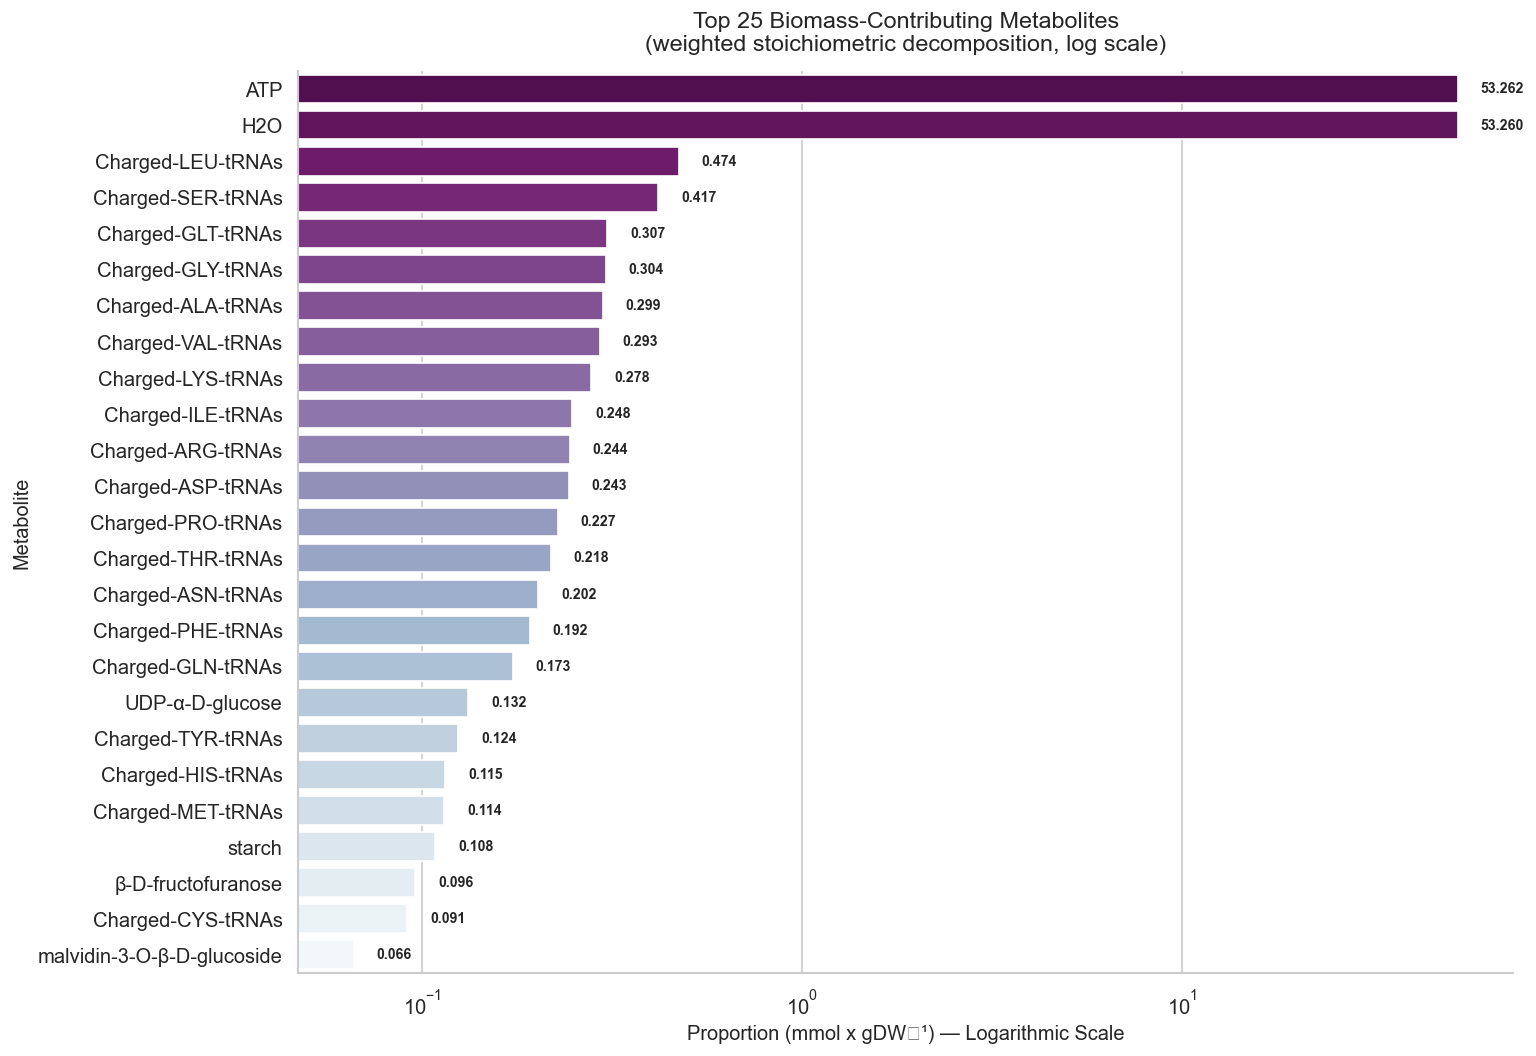

In [14]:
fig, ax = plt.subplots(figsize = (13, 9))

pal = sns.color_palette(PALETTE_MAIN, len(df_top25))
sns.barplot(data = df_top25,
            x       = 'Proportion (mmol/gDW)',
            y       = 'Metabolite Name',
            palette = pal,
            hue     = 'Metabolite Name',
            legend  = False,
            ax      = ax)

ax.set_xscale('log')
ax.set_title('Top 25 Biomass-Contributing Metabolites\n'
             '(weighted stoichiometric decomposition, log scale)',
             fontsize = 14, pad = 12)
ax.set_xlabel(r'Proportion (mmol x gDW⁻¹) — Logarithmic Scale', fontsize = 12)
ax.set_ylabel('Metabolite', fontsize = 12)

for bar in ax.patches:
    w = bar.get_width()
    ax.text(w * 1.15, bar.get_y() + bar.get_height()/2,
            f'{w:.3f}', va = 'center', fontsize = 8.5, fontweight = 'bold')

plt.tight_layout()
# plt.savefig('fig1_top25_biomass.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 3. Network Topology
### 3.1 Global Statistics

In [15]:
n_genes       = len(berry_model.genes)
n_metabolites = len(berry_model.metabolites)
n_comps       = len(berry_model.compartments)
n_reactions   = len(berry_model.reactions)
n_ex          = len(berry_model.exchanges)
bound_as_ex   = [r for r in berry_model.exchanges if r.id.startswith('EX_')]
n_dem         = len(berry_model.demands)
n_snk         = len(berry_model.sinks)
n_gpr         = sum(1 for r in berry_model.reactions if r.gene_reaction_rule.strip())

print(f'Genes                      : {n_genes}')
print(f'Metabolites                : {n_metabolites}')
print(f'Compartments               : {n_comps}')
print(f'Reactions                  : {n_reactions}')
print(f'Exchange reactions         : {n_ex}')
print(f'    EX_ reactions counted as exchanges : {len(bound_as_ex)}')
print(f'Demand reactions           : {n_dem}')
print(f'Sink reactions             : {n_snk}')
print(f'Reactions with GPR rules   : {n_gpr}')
print(f'Metabolites/Reaction ratio : {n_metabolites/n_reactions:.2f}')

Genes                      : 7199
Metabolites                : 5143
Compartments               : 10
Reactions                  : 4272
Exchange reactions         : 241
    EX_ reactions counted as exchanges : 241
Demand reactions           : 0
Sink reactions             : 0
Reactions with GPR rules   : 3697
Metabolites/Reaction ratio : 1.20


### 3.2 Subsystem Distribution
Count reactions per biological subsystem.

Total subsystems: 764


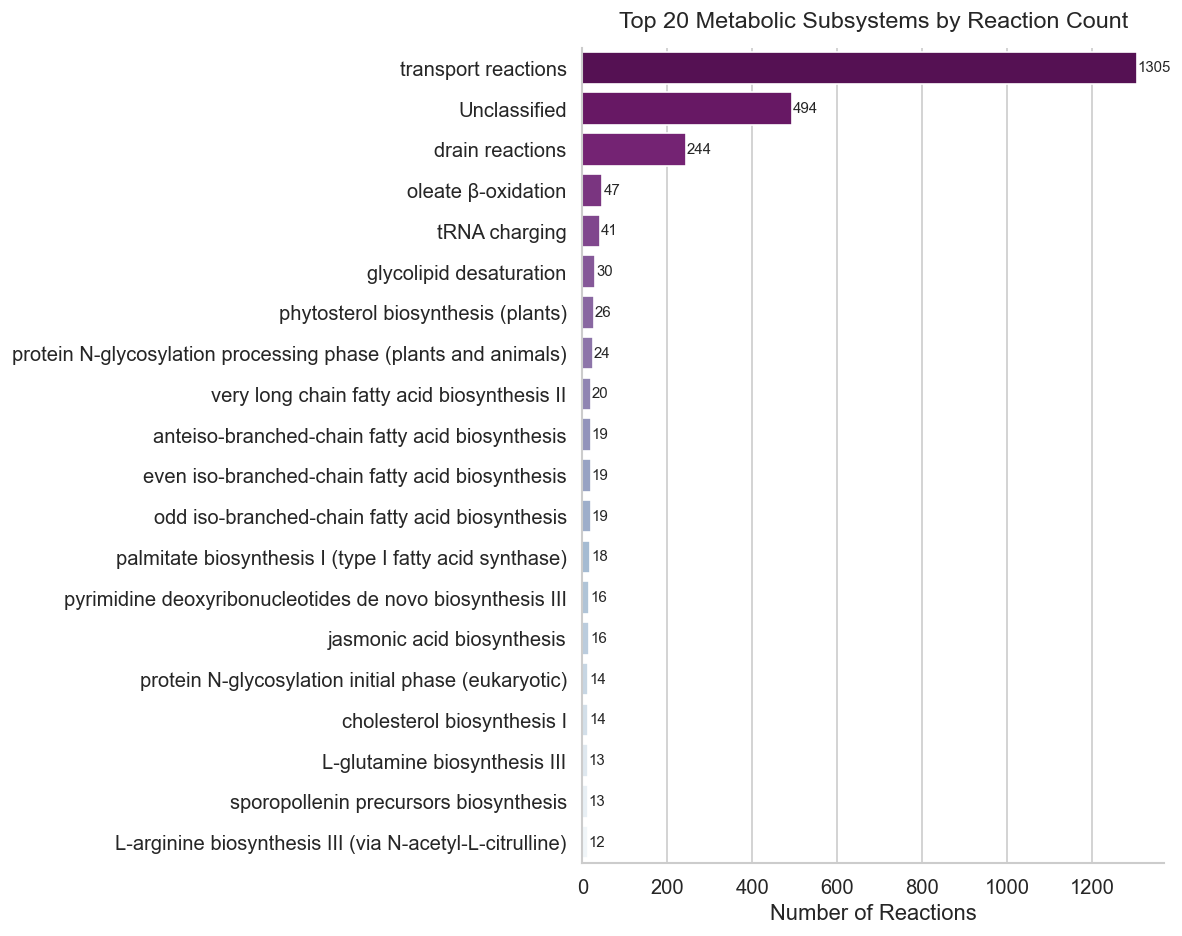

In [16]:
subsystem_counts = (pd.Series([r.subsystem for r in berry_model.reactions], name = 'count')
                    .value_counts()
                    .rename_axis('Subsystem')
                    .reset_index())
subsystem_counts.columns = ['Subsystem', 'Reactions']
subsystem_counts['Subsystem'] = subsystem_counts['Subsystem'].replace('', 'Unclassified')
subsystem_counts['Subsystem'] = subsystem_counts['Subsystem'].apply(html_lib.unescape)

top_n      = 20
top_subsys = subsystem_counts.head(top_n).copy()

print(f'Total subsystems: {subsystem_counts.shape[0]}')

fig, ax = plt.subplots(figsize = (10, 8))
pal     = sns.color_palette(PALETTE_MAIN, len(top_subsys))
sns.barplot(data = top_subsys, 
            y       = 'Subsystem', 
            x       = 'Reactions',
            palette = pal,
            hue     = 'Subsystem', 
            legend  = False, 
            ax      = ax)
ax.set_title(f'Top {top_n} Metabolic Subsystems by Reaction Count', fontsize = 14, pad = 12)
ax.set_xlabel('Number of Reactions')
ax.set_ylabel('')
for bar in ax.patches:
    ax.text(bar.get_width() + 2, 
            bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', 
            va       = 'center', 
            fontsize = 9)
plt.tight_layout()
# plt.savefig('fig2_subsystem_distribution.png', dpi = 150, bbox_inches = 'tight')
plt.show()
print()

### 3.3 Metabolite and Reaction Catalogues

In [17]:
# Metabolite catalogue
df_metabolites = pd.DataFrame([{'ID': m.id, 'Name': m.name, 'Formula': m.formula,
                                'Compartment': m.compartment, 'Charge': m.charge,
                                'Annotations': str(m.annotation)}
                                for m in berry_model.metabolites])

# Reaction catalogue
df_reactions = pd.DataFrame([{'ID': r.id, 'Name': r.name, 'GPR Rule': r.gene_reaction_rule,
                              'Subsystem': r.subsystem, 'Equation': r.reaction,
                              'Lower Bound': r.lower_bound, 'Upper Bound': r.upper_bound}
                               for r in berry_model.reactions])

# Uncomment to export
# df_metabolites.to_excel('VvM_metabolites.xlsx', index = False)
# df_reactions.to_excel('VvM_reactions.xlsx', index = False)

## 4. Essentiality Analysis
### 4.1 Essential Reactions

In [18]:
essential_rxns = find_essential_reactions(berry_model, processes = 1)
n_ess          = len(essential_rxns)
essential_ids  = {r.id for r in essential_rxns}
print(f'Essential reactions : {n_ess} ({n_ess/n_reactions*100:.1f}% of {n_reactions})')
print(f'Non-essential       : {n_reactions - n_ess} ({(n_reactions-n_ess)/n_reactions*100:.1f}%)')

Essential reactions : 334 (7.8% of 4272)
Non-essential       : 3938 (92.2%)


#### 4.1.1 Essential Reactions by Subsystem
Breakdown of essential reactions across biological subsystems.

**Subsystem annotation errors:** Several reactions carry subsystem labels inherited from non-plant databases (e.g., "flavin biosynthesis III (fungi)", "streptorubin B biosynthesis"). These are legitimate plant reactions (chloroplast riboflavin synthesis, fatty acid elongation) with incorrect pathway attribution. No functional impact on flux calculations.

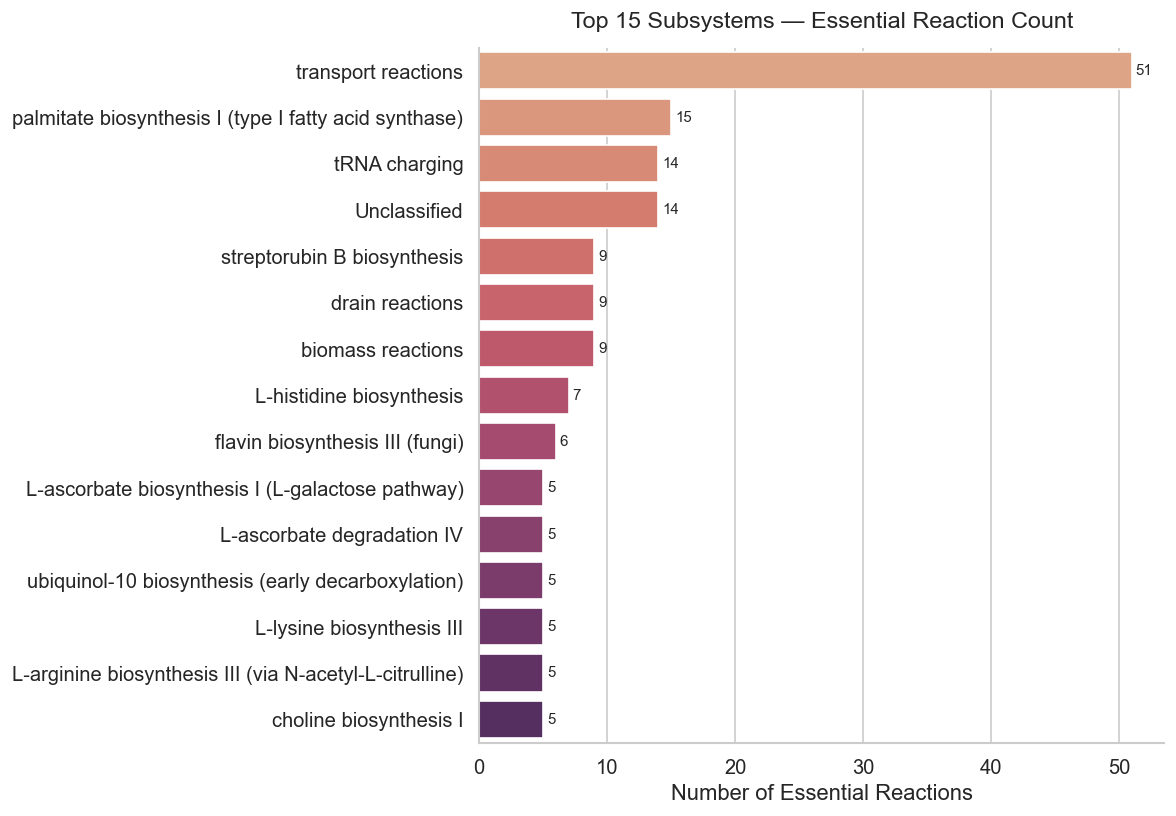

In [19]:
essential_subsys = (pd.Series([berry_model.reactions.get_by_id(rid).subsystem or 'Unclassified'
                               for rid in essential_ids],
                               name = 'count')
                    .value_counts()
                    .rename_axis('Subsystem')
                    .reset_index())
essential_subsys.columns = ['Subsystem', 'Essential Reactions']

top_ess = essential_subsys.head(15)

fig, ax = plt.subplots(figsize = (10, 7))
sns.barplot(data    = top_ess, 
            y       = 'Subsystem', 
            x       = 'Essential Reactions',
            palette = sns.color_palette('flare', len(top_ess)),
            hue     = 'Subsystem', 
            legend  = False, 
            ax      = ax)
ax.set_title('Top 15 Subsystems — Essential Reaction Count', fontsize = 14, pad = 12)
ax.set_xlabel('Number of Essential Reactions')
ax.set_ylabel('')
for bar in ax.patches:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}', va='center', fontsize=9)
plt.tight_layout()
# plt.savefig('fig3_essential_subsystems.png', dpi = 150, bbox_inches = 'tight')
plt.show()


### 4.2 Gene Essentiality

The low essentiality rate ($1.0%$) reflects high genetic redundancy in the mature berry model, likely due to multi-compartment isoenzymes and the large number of paralogue genes in *V. vinifera* ($7199$ genes).

Total genes in model       : 7199
Essential genes identified : 74
Non-essential genes        : 7125
Essentiality rate          : 1.0%


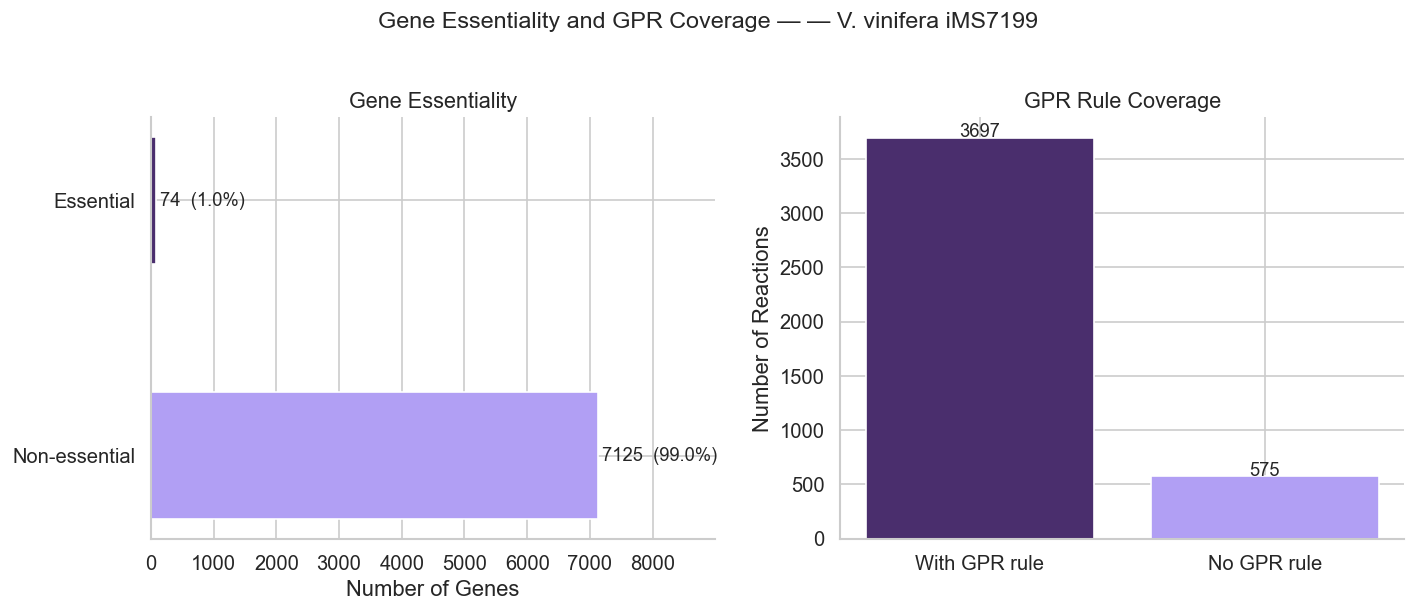

In [20]:
essential_genes    = find_essential_genes(berry_model, processes=1)
essential_gene_ids = {g.id for g in essential_genes}
n_ess              = len(essential_gene_ids)

print(f'Total genes in model       : {n_genes}')
print(f'Essential genes identified : {len(essential_gene_ids)}')
print(f'Non-essential genes        : {n_genes - len(essential_gene_ids)}')
print(f'Essentiality rate          : {len(essential_gene_ids)/n_genes*100:.1f}%')

n_non    = n_genes - n_ess
n_no_gpr = sum(1 for r in berry_model.reactions if not r.gene_reaction_rule)
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Left:
axes[0].barh(['Non-essential', 'Essential'],
             [n_non, n_ess],
             color     = ['#B19FF4', '#4A2E6D'], 
             edgecolor = 'white', 
             height    = 0.5)
for bar, val, pct in zip(axes[0].patches,
                          [n_non, n_ess],
                          [n_non/n_genes*100, n_ess/n_genes*100]):
    axes[0].text(bar.get_width() + n_genes*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val}  ({pct:.1f}%)', 
                 va = 'center', 
                 fontsize = 11)
axes[0].set_xlim(0, n_genes * 1.25)
axes[0].set_xlabel('Number of Genes')
axes[0].set_title('Gene Essentiality', fontsize = 13)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right:
n_with_gpr = n_reactions - n_no_gpr
axes[1].bar(['With GPR rule', 'No GPR rule'], 
            [n_with_gpr, n_no_gpr],
            color = ['#4A2E6D', '#B19FF4'], 
            edgecolor = 'white')
axes[1].set_title('GPR Rule Coverage', fontsize = 13)
axes[1].set_ylabel('Number of Reactions')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5, 
                 str(int(bar.get_height())),
                 ha = 'center', 
                 fontsize = 11)

plt.suptitle('Gene Essentiality and GPR Coverage — — V. vinifera iMS7199', fontsize = 14, y = 1.02)
plt.tight_layout()
# plt.savefig('fig4_gene_essentiality.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 5. Model Consistency
### 5.1 Blocked Reactions

In [21]:
blocked_ids = find_blocked_reactions(berry_model, processes = 1)
n_blocked   = len(blocked_ids)

with berry_model:
    for rxn in berry_model.exchanges:
        rxn.lower_bound = -1000
    blocked_rich = find_blocked_reactions(berry_model, processes = 1)

n_struct  = len(blocked_rich)
n_environ = n_blocked - n_struct

print(f'Blocked reactions (default medium) : {n_blocked} ({n_blocked/n_reactions*100:.1f}%)')
print(f'Structurally blocked               : {n_struct} ({n_struct/n_reactions*100:.1f}%)')
print(f'Environmentally blocked            : {n_environ} ({n_environ/n_reactions*100:.1f}%)')

Blocked reactions (default medium) : 1979 (46.3%)
Structurally blocked               : 1927 (45.1%)
Environmentally blocked            : 52 (1.2%)


#### 5.1.1 Blocked Reaction Profile — Developmental Context

The $46.3\%$ blocked reaction rate reflects *post-veraison* metabolic silencing.

**Key findings:**
* `homogalacturonan biosynthesis` is 100% blocked — the berry cannot synthesise new pectin (*A. niger* pectinase-mediated cell wall degradation is therefore irreversible).
* `oxalate degradation III` is 75% blocked (*A. niger* oxalic acid secretion will accumulate in the intercellular space, progressively acidifying the infection site).
* `jasmonic acid biosynthesis` is 93.8% blocked (wound-response pathways are silenced during ripening, reducing the berry's ability to mount a defence response).
* `phenylpropanoid biosynthesis` remains 60% active — flavonoid and lignin biosynthesis represents the primary active antifungal defence layer.
* Several 100%-blocked subsystems are cross-species annotation artefacts.

In [22]:
blocked_data = []
for rxn_id in blocked_ids:
    try:
        rxn = berry_model.reactions.get_by_id(rxn_id)
        blocked_data.append({'Reaction'  : rxn_id,
                             'Name'      : rxn.name,
                             'Subsystem' : rxn.subsystem or 'Unknown',})
    except: pass

df_blocked = pd.DataFrame(blocked_data)

subsystem_counts = {}
for rxn in berry_model.reactions:
    sub = rxn.subsystem or 'Unknown'
    subsystem_counts[sub] = subsystem_counts.get(sub, 0) + 1

blocked_by_sub = df_blocked.groupby('Subsystem').size().reset_index(name='Blocked')
blocked_by_sub['Total']      = blocked_by_sub['Subsystem'].map(subsystem_counts)
blocked_by_sub['Blocked (%)'] = blocked_by_sub['Blocked'] / blocked_by_sub['Total'] * 100

blocked_merged = blocked_by_sub.sort_values('Blocked (%)', ascending=False)

blocked_merged['Subsystem'] = blocked_merged['Subsystem'].apply(html_lib.unescape)

fully_blocked     = blocked_merged[blocked_merged['Blocked (%)'] >= 95].copy()
partially_blocked = blocked_merged[(blocked_merged['Blocked (%)'] >= 50) &
                                   (blocked_merged['Blocked (%)'] < 95)].copy()
mostly_active     = blocked_merged[blocked_merged['Blocked (%)'] < 50].copy()

print('Developmental Stage Interpretation of Blocked Reactions')
print('_' * 60)
print(f'\nFully silenced subsystems (≥95% blocked): {len(fully_blocked)}')
for _, row in fully_blocked.head(10).iterrows():
    print(f'  {row["Subsystem"][:55]:<55} ({row["Blocked (%)"]:>5.1f}%)')

print(f'\nMostly silenced subsystems (50-95% blocked): {len(partially_blocked)}')
for _, row in partially_blocked.head(10).iterrows():
    print(f'  {row["Subsystem"][:55]:<55} ({row["Blocked (%)"]:>5.1f}%)')

print(f'\nMostly active subsystems (<50% blocked): {len(mostly_active)}')
for _, row in mostly_active.head(10).iterrows():
    print(f'  {row["Subsystem"][:55]:<55} ({row["Blocked (%)"]:>5.1f}%)')

Developmental Stage Interpretation of Blocked Reactions
____________________________________________________________

Fully silenced subsystems (≥95% blocked): 408
  α-linolenate biosynthesis I (plants and red algae)      (100.0%)
  methylglyoxal degradation VI                            (100.0%)
  methylglyoxal degradation I                             (100.0%)
  methylamine degradation II                              (100.0%)
  matairesinol biosynthesis                               (100.0%)
  lysine degradation II                                   (100.0%)
  luteolin glycosides biosynthesis                        (100.0%)
  lutein biosynthesis                                     (100.0%)
  lupulone and humulone biosynthesis                      (100.0%)
  lotaustralin biosynthesis                               (100.0%)

Mostly silenced subsystems (50-95% blocked): 59
  jasmonic acid biosynthesis                              ( 93.8%)
  3-phosphoinositide degradation                  

### 5.2 Mass Balance Validation
Assess stoichiometric consistency. Exchange reactions and macromolecular pool reactions (e-Biomass, e-Protein, e-Lipids, etc.) are excluded as expected unbalanced entries.

**Known issues:**
* `RXN0-5184__chlo`: discrepancy of C: $−84$, H: $−140$, O: $−70$ (equivalent to $14$ glucose units) — likely incorrect polysaccharide stoichiometry in the chloroplast. The error is not expected to affect the primary carbon/energy fluxes relevant to the simulations.

In [23]:
bad_rxns = []
for r in berry_model.reactions:
    errors = r.check_mass_balance()
    if errors:
        bad_rxns.append({'ID': r.id, 'Name': r.name, 'Errors': str(errors)})

df_bad = pd.DataFrame(bad_rxns)
n_bad = len(df_bad)

# Exclude exchange reactions and macromolecular pool reactions (artificial)
exclude_prefixes = ('EX_', 'e-')
df_internal_bad  = df_bad[~df_bad['ID'].apply(
    lambda x: any(x.startswith(p) for p in exclude_prefixes))]

n_excluded = n_bad - len(df_internal_bad)
n_int_bad  = len(df_internal_bad)

print(f'Reactions with mass discrepancies : {n_bad}')
print(f'  Exchange/pool (expected)        : {n_excluded}')
print(f'  Internal reactions (inspect)    : {n_int_bad}')

if n_int_bad > 0:
    print('\nInternal reactions with mass balance errors:')
    print(df_internal_bad[['ID', 'Name', 'Errors']].to_string(index=False))

Reactions with mass discrepancies : 252
  Exchange/pool (expected)        : 251
  Internal reactions (inspect)    : 1

Internal reactions with mass balance errors:
             ID      Name                                Errors
RXN0-5184__chlo RXN0-5184 {'C': -84.0, 'H': -140.0, 'O': -70.0}


### 5.3 Flux Variability Analysis
Transport reactions (TR/TO/TZ/T_ prefixes, bounds $±999999$) are excluded from unbounded analysis (DEFAULT_BOUND = $10000.0$).

In [24]:
with berry_model:
    fva_full = flux_variability_analysis(berry_model, fraction_of_optimum = 0.0, processes = 1)
with berry_model:
    fva_opt  = flux_variability_analysis(berry_model, fraction_of_optimum = 1.0, processes = 1)

# iMS7199 convention: transport reactions use bounds ±999999 (effectively unlimited)
# Use 10000.0 as DEFAULT_BOUND for metabolic reaction analysis
DEFAULT_BOUND      = 10000.0
transport_prefixes = ('TR', 'TO', 'TZ', 'T_')

unbounded = fva_full[(fva_full['minimum'] <= -DEFAULT_BOUND) &
                     (fva_full['maximum'] >=  DEFAULT_BOUND)]

unbounded_transport  = unbounded[unbounded.index.str.startswith(transport_prefixes)]
unbounded_metabolic  = unbounded[~unbounded.index.str.startswith(transport_prefixes)]

print(f'Unbounded transport reactions : {len(unbounded_transport)}')
print(f'Unbounded metabolic reactions : {len(unbounded_metabolic)}')

Unbounded transport reactions : 151
Unbounded metabolic reactions : 41


## 6. Exchange Flux Profile

**Convention:** negative values = uptake; positive values = secretion.

In [25]:
fba_solution = berry_model.optimize()

exchange_fluxes = {rxn.id: fba_solution.fluxes[rxn.id]
                   for rxn in berry_model.exchanges
                   if abs(fba_solution.fluxes.get(rxn.id, 0)) > 1e-6}

df_exch = (pd.DataFrame.from_dict(exchange_fluxes, orient = 'index', columns = ['Flux'])
           .rename_axis('Reaction ID')
           .assign(Direction  = lambda d: d['Flux'].apply(lambda x: 'Uptake' if x < 0 else 'Secretion'),
                   Metabolite = lambda d: d.index.map(lambda rid: html_lib.unescape(berry_model.reactions.get_by_id(rid).reactants[0].name
                                                                                  if berry_model.reactions.get_by_id(rid).reactants else rid)))
           .sort_values('Flux')
           .reset_index())

print(df_exch[['Metabolite', 'Reaction ID', 'Flux', 'Direction']].to_string(index = False))

       Metabolite              Reaction ID      Flux Direction
               H+          EX_PROTON_drain -5.338236    Uptake
           oxygen EX_OXYGEN-MOLECULE_drain -2.440272    Uptake
          sucrose         EX_SUCROSE_drain -1.000000    Uptake
          nitrate         EX_NITRATE_drain -0.976275    Uptake
          sulfate         EX_SULFATE_drain -0.032152    Uptake
        phosphate              EX_Pi_drain -0.000117    Uptake
              H2O           EX_WATER_drain  1.766176 Secretion
hydrogencarbonate            EX_HCO3_drain  4.714053 Secretion


## 7. Shadow Prices and Reduced Costs
### 7.1 Shadow Prices

**Notes:**
* The dominant shadow prices reflect membrane lipid precursors across multiple compartments — structural components required for berry membrane maintenance.

Non-zero shadow prices : 2448
Non-zero reduced costs : 406

Exchangeable metabolites with shadow price: 67


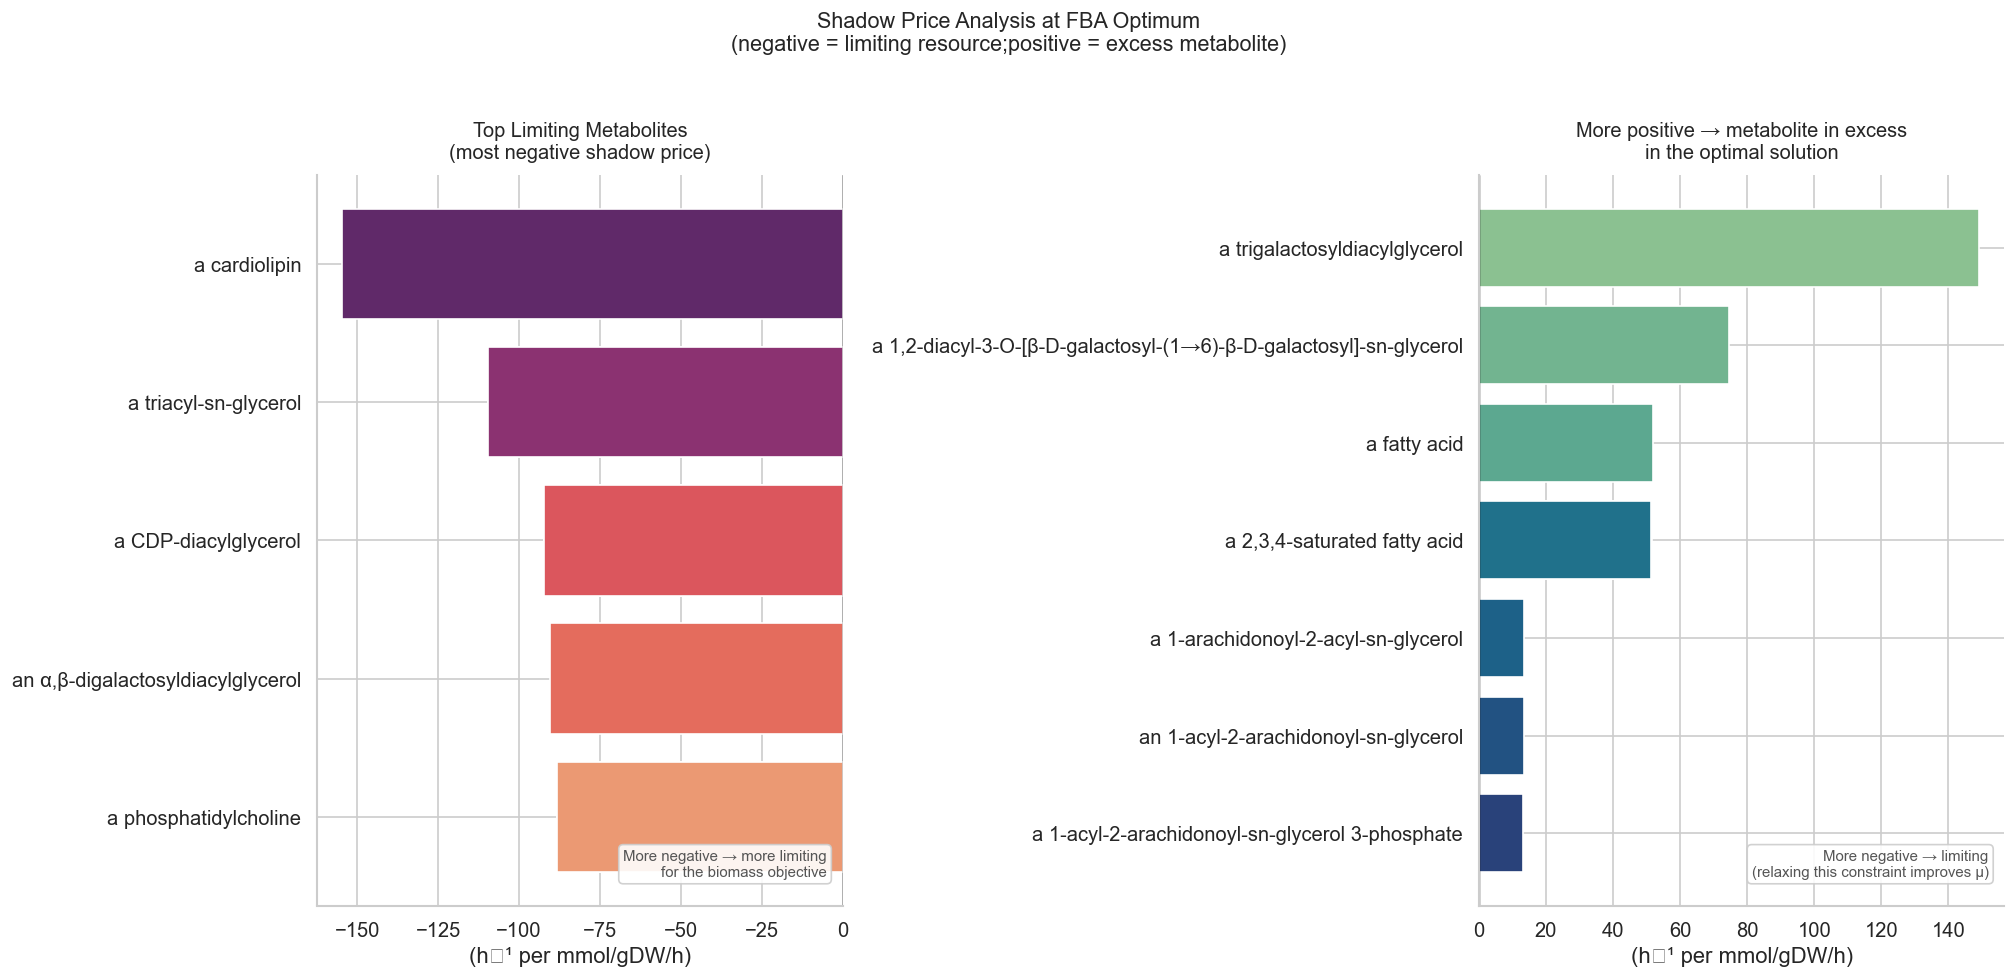

In [26]:
shadow  = fba_solution.shadow_prices.dropna()
reduced = fba_solution.reduced_costs.dropna()

shadow_nonzero = shadow[shadow.abs() > 1e-9]
print(f'Non-zero shadow prices : {len(shadow_nonzero)}')
print(f'Non-zero reduced costs : {(reduced.abs() > 1e-9).sum()}')

def met_name(mid):
    try:
        return html_lib.unescape(berry_model.metabolites.get_by_id(mid).name)
    except Exception:
        return mid
def met_comp(mid):
    try:
        return berry_model.metabolites.get_by_id(mid).compartment
    except Exception:
        return 'n/a'

top_shadow_neg = shadow_nonzero.nsmallest(10)
top_shadow_pos = shadow_nonzero.nlargest(10)

df_shadow_neg = pd.DataFrame({'Metabolite'  : [met_name(i) for i in top_shadow_neg.index],
                              'ID'          : list(top_shadow_neg.index),
                              'Compartment' : [met_comp(i) for i in top_shadow_neg.index],
                              'Shadow Price': top_shadow_neg.values})

df_shadow_pos = pd.DataFrame({'Metabolite'  : [met_name(i) for i in top_shadow_pos.index],
                              'ID'          : list(top_shadow_pos.index),
                              'Compartment' : [met_comp(i) for i in top_shadow_pos.index],
                              'Shadow Price': top_shadow_pos.values})

exchangeable_mets = {m.id for rxn in berry_model.exchanges
                     for m in rxn.metabolites
                     if m.compartment == 'e'}

shadow_exch = shadow_nonzero[shadow_nonzero.index.isin(exchangeable_mets)]
print(f'\nExchangeable metabolites with shadow price: {len(shadow_exch)}')

exch_top10 = shadow_exch.nsmallest(10)
df_exch_shadow = pd.DataFrame({'Metabolite' : [met_name(i) for i in exch_top10.index],
                               'ID'         : list(exch_top10.index),
                               'Compartment': [met_comp(i) for i in exch_top10.index],
                               'Shadow Price': exch_top10.values})

fig, axes = plt.subplots(1, 2, figsize = (17, 8))

# Left
pal_neg = sns.color_palette('flare_r', len(df_shadow_neg))
axes[0].barh(df_shadow_neg['Metabolite'], 
             df_shadow_neg['Shadow Price'],
             color     = pal_neg, 
             edgecolor = 'white')
axes[0].axvline(0, color = 'black', linewidth = 0.8)
axes[0].set_xlabel('(h⁻¹ per mmol/gDW/h)')
axes[0].set_title('Top Limiting Metabolites\n(most negative shadow price)',
                  fontsize = 12, pad = 10)
axes[0].invert_yaxis()
axes[0].annotate('More negative → more limiting\nfor the biomass objective',
                 xy       = (0.97, 0.04), 
                 xycoords = 'axes fraction',
                 ha       = 'right',
                 fontsize = 9,
                 color    = '#555',
                 bbox     = dict(boxstyle = 'round, pad = 0.3', fc = 'white', ec = '#ccc', alpha = 0.9))

# Right
pal_pos = sns.color_palette('crest', len(df_shadow_pos))
axes[1].barh(df_shadow_pos['Metabolite'], df_shadow_pos['Shadow Price'], color = pal_pos, edgecolor = 'white')
axes[1].axvline(0, color = 'black', linewidth = 0.8)
axes[1].set_xlabel('(h⁻¹ per mmol/gDW/h)')
axes[1].set_title('More positive → metabolite in excess\nin the optimal solution', fontsize = 12, pad = 10)
axes[1].invert_yaxis()
axes[1].annotate('More negative → limiting\n(relaxing this constraint improves μ)',
                 xy       = (0.97, 0.04), 
                 xycoords = 'axes fraction',
                 ha       = 'right', 
                 fontsize = 9, 
                 color    = '#555',
                 bbox     = dict(boxstyle = 'round, pad = 0.3', fc = 'white', ec = '#ccc', alpha = 0.9))

plt.suptitle('Shadow Price Analysis at FBA Optimum\n'
    '(negative = limiting resource;''positive = excess metabolite)', fontsize = 13, y = 1.02)
plt.tight_layout()
# plt.savefig('fig5_shadow_prices.png', dpi = 150, bbox_inches = 'tight')
plt.show()

### 7.2 Reduced Costs
All top reactions carry negative reduced costs. The dominant outlier (`L-1-PHOSPHATIDYL-ETHANOLAMINE_drain`, $−162.0$) reflects the extreme lipid limitation identified in shadow price analysis.

In [27]:
def rxn_name(rid):
    try:
        return html_lib.unescape(berry_model.reactions.get_by_id(rid).name or rid)
    except Exception:
        return rid

top_rc = reduced.abs().nlargest(15)
df_rc  = pd.DataFrame({'Reaction'     : [rxn_name(i) for i in top_rc.index],
                       'ID'           : list(top_rc.index),
                       'Reduced Cost' : reduced[top_rc.index].values,})
print(df_rc[['ID', 'Reaction', 'Reduced Cost']].to_string(index = False))

                                     ID                            Reaction  Reduced Cost
 EX_L-1-PHOSPHATIDYL-ETHANOLAMINE_drain L-1-PHOSPHATIDYL-ETHANOLAMINE_drain   -161.983163
                        RXN-12203__chlo                           RXN-12203     -3.619291
                        RXN-12280__chlo                           RXN-12280     -2.296858
                        RXN0-5184__chlo                           RXN0-5184     -2.296858
                        RXN-14378__chlo                           RXN-14378     -1.804674
                      1.14.19.3-RXN__er                       1.14.19.3-RXN     -1.755787
                          RXN-11680__er                           RXN-11680     -1.755787
1-PHOSPHATIDYLINOSITOL-KINASE-RXN__cyto   1-PHOSPHATIDYLINOSITOL-KINASE-RXN     -1.667061
                        RXN-10964__cyto                           RXN-10964     -1.478142
               EX_CARBON-MONOXIDE_drain               CARBON-MONOXIDE_drain     -1.274582
          

## 8. Robustness Analysis
### 8.1 Sucrose Uptake vs. Biomass Production
Scan sucrose uptake rate ($0–20 mmol·gDW⁻¹·h⁻¹$, $80$ points) to extract 
the growth slope for dFBA parametrisation.

The model is infeasible at sucrose = $0$, confirming sucrose is the sole 
viable carbon source. The relationship is perfectly linear ($R² = 1.0$) 
across the full feasible range, with slope GROWTH_SLOPE_VV = $0.15909 
h⁻¹$ per mmol/gDW/h. The slightly negative intercept ($−0.00497 h⁻¹$) 
is a numerical artefact of excluding the infeasible point at sucrose = $0$ 
from the linear fit.

Scan range    : 0.0 – 20.0 mmol/gDW/h (80 points)
Infeasible    : 1 point(s) — model has no viable carbon alternative
Optimal       : 79 point(s)

Slope                   = 0.15909 h⁻¹ per mmol/gDW/h
Intercept               = -0.00497 h⁻¹
Linear fit R²           = 1.000000
Min viable sucrose rate = 0.0312 mmol/gDW/h


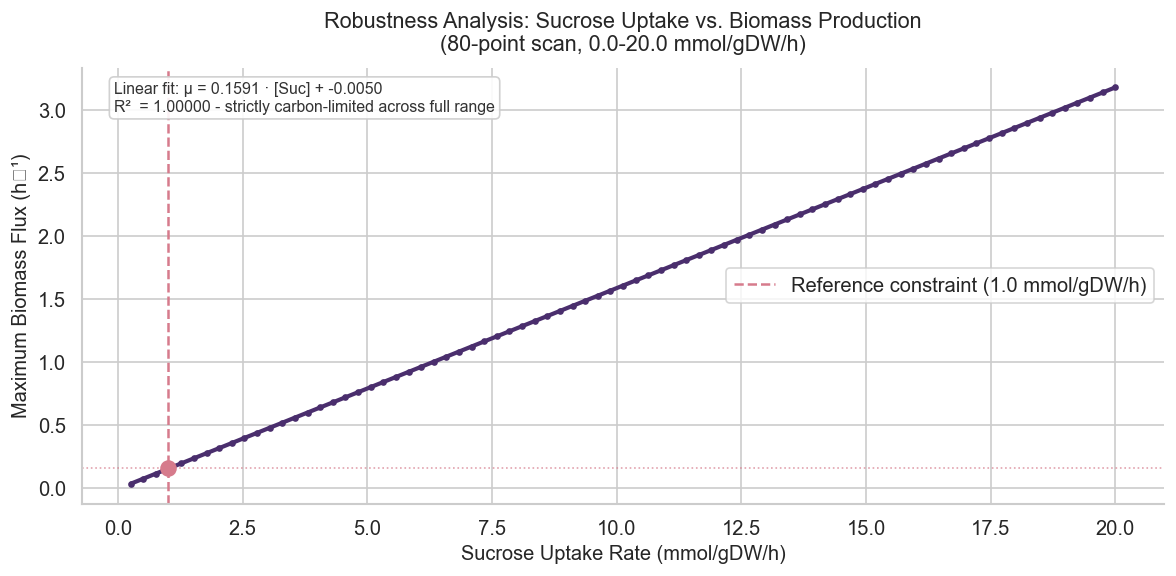

In [28]:
SCAN_MIN    = 0.0
SCAN_MAX    = 20.0
N_POINTS    = 80

scan_values  = np.linspace(SCAN_MIN, SCAN_MAX, N_POINTS)
biomass_vals = []
statuses     = []

for rate in scan_values:
    with berry_model:
        berry_model.reactions.get_by_id(SUCROSE_RXN).lower_bound = -rate
        sol = berry_model.optimize()
        biomass_vals.append(sol.objective_value if sol.status == 'optimal' else np.nan)
        statuses.append(sol.status)

df_robust = pd.DataFrame({'Sucrose Uptake Rate': scan_values,
                          'Biomass Flux'       : biomass_vals,
                          'Status'             : statuses})

n_infeasible = df_robust['Status'].eq('infeasible').sum()
n_optimal    = df_robust['Status'].eq('optimal').sum()
print(f'Scan range    : {SCAN_MIN} – {SCAN_MAX} mmol/gDW/h ({N_POINTS} points)')
print(f'Infeasible    : {n_infeasible} point(s) — model has no viable carbon alternative')
print(f'Optimal       : {n_optimal} point(s)')

valid = df_robust.dropna(subset=['Biomass Flux'])

x      = valid['Sucrose Uptake Rate'].values
y      = valid['Biomass Flux'].values
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)

GROWTH_SLOPE     = coeffs[0]
GROWTH_INTERCEPT = coeffs[1]
GROWTH_R2        = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)

print(f'\nSlope                   = {GROWTH_SLOPE:.5f} h⁻¹ per mmol/gDW/h')
print(f'Intercept               = {GROWTH_INTERCEPT:.5f} h⁻¹')
print(f'Linear fit R²           = {GROWTH_R2:.6f}')

min_rate_VV = max(0.0, -GROWTH_INTERCEPT / GROWTH_SLOPE)
print(f'Min viable sucrose rate = {min_rate_VV:.4f} mmol/gDW/h')

fig, ax = plt.subplots(figsize = (10, 5))
ax.plot(valid['Sucrose Uptake Rate'], 
        valid['Biomass Flux'],
        color      = '#4A2E6D', 
        linewidth  = 2.5, 
        marker     = 'o', 
        markersize = 3)

ref_rate    = 1.0
ref_row     = valid.iloc[(valid['Sucrose Uptake Rate'] - ref_rate).abs().argsort().iloc[0]]
ref_biomass = ref_row['Biomass Flux']
ax.axvline(ref_rate, 
           color     = '#D67B8C', 
           linestyle = '--', 
           linewidth = 1.5,
           label     = f'Reference constraint ({ref_rate} mmol/gDW/h)')
ax.axhline(ref_biomass, color = '#D67B8C', linestyle = ':', linewidth = 1, alpha = 0.7)
ax.scatter([ref_rate], [ref_biomass], color = '#D67B8C', zorder = 5, s = 80)

ax.annotate(f'Linear fit: μ = {GROWTH_SLOPE:.4f} · [Suc] + {GROWTH_INTERCEPT:.4f}\n'
            f'R²  = {GROWTH_R2:.5f} - strictly carbon-limited across full range',
            xy = (0.03, 0.90), 
            xycoords = 'axes fraction',
            fontsize = 9.5, 
            color    = '#333',
            bbox     = dict(boxstyle = 'round, pad = 0.3', fc = 'white', ec = '#ccc', alpha = 0.9))

ax.set_xlabel('Sucrose Uptake Rate (mmol/gDW/h)', fontsize = 12)
ax.set_ylabel('Maximum Biomass Flux (h⁻¹)', fontsize = 12)
ax.set_title(f'Robustness Analysis: Sucrose Uptake vs. Biomass Production\n'
             f'({N_POINTS}-point scan, {SCAN_MIN}-{SCAN_MAX} mmol/gDW/h)',
             fontsize = 13, pad = 10)
ax.legend()
plt.tight_layout()
# plt.savefig('fig6_robustness_sucrose.png', dpi = 150, bbox_inches = 'tight')
plt.show()

### 8.2 Multi-Nutrient Co-limitation Analysis
Scan growth at multiple O₂ levels ($25–100\%$ of FBA optimum) to identify 
aerobic–fermentative transition boundaries.

**Result:** Although no O₂ saturation threshold was detected, O₂ 
availability systematically reduces the growth yield per unit sucrose 
(μ_max decreases from $0.328 h⁻¹$ at $100\%$ O₂ to $0.228 h⁻¹$ at $25\%$ O₂). 
The mature berry is simultaneously **carbon-limited and oxygen-sensitive**.

In [29]:
o2_cands  = [r for r in berry_model.exchanges
              if any(k in r.id.upper() for k in ['O2', 'OXYGEN'])
              and r.lower_bound < 0]
no3_cands = [r for r in berry_model.exchanges
              if any(k in r.id.upper() for k in ['NO3', 'NITRAT', 'NITR'])
              and r.lower_bound < 0]

if not o2_cands:
    o2_cands = [r for r in berry_model.exchanges
                if any('oxygen' in m.name.lower() for m in r.metabolites)
                and r.lower_bound < 0]

print(f'O₂ exchange reaction  : {O2_RXN}')
print(f'NO₃ exchange reaction : {NO3_RXN}')

# Baseline values from FBA solution
O2_BASELINE  = abs(fba_solution.fluxes.get(O2_RXN,  2.44)) if O2_RXN  else 2.44
NO3_BASELINE = abs(fba_solution.fluxes.get(NO3_RXN, 0.98)) if NO3_RXN else 0.98
print(f'O₂ baseline flux      : {O2_BASELINE:.4f} mmol/gDW/h')
print(f'NO₃ baseline flux     : {NO3_BASELINE:.4f} mmol/gDW/h')

O₂ exchange reaction  : EX_OXYGEN-MOLECULE_drain
NO₃ exchange reaction : EX_NITRATE_drain
O₂ baseline flux      : 2.4403 mmol/gDW/h
NO₃ baseline flux     : 0.9763 mmol/gDW/h


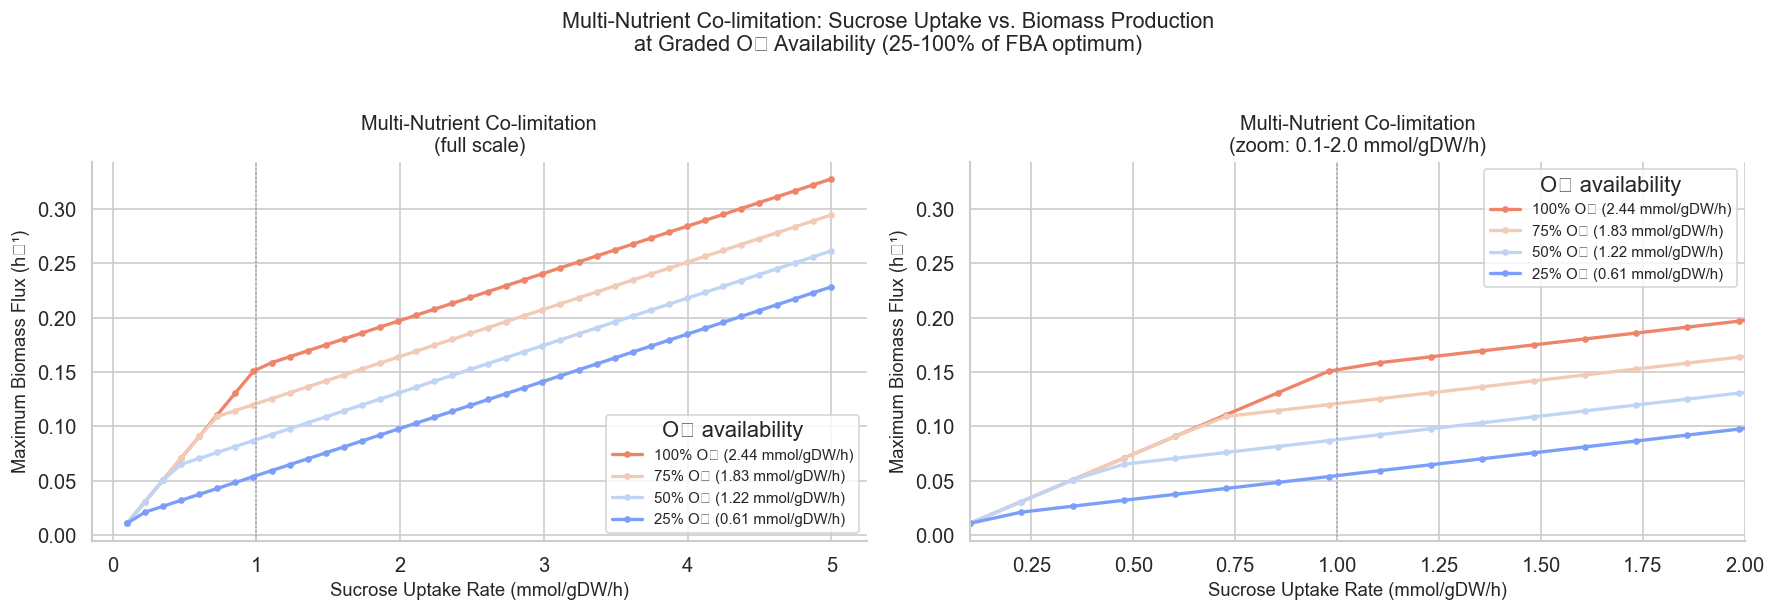

Co-limitation thresholds (sucrose rate at which 25% O₂ limit becomes binding):
  O₂ = 100%: no saturation detected in scanned range (μ_max ≈ 0.3278 h⁻¹)
  O₂ = 75%: no saturation detected in scanned range (μ_max ≈ 0.2947 h⁻¹)
  O₂ = 50%: no saturation detected in scanned range (μ_max ≈ 0.2615 h⁻¹)
  O₂ = 25%: no saturation detected in scanned range (μ_max ≈ 0.2284 h⁻¹)


In [30]:
o2_fractions = [1.0, 0.75, 0.5, 0.25]
suc_scan     = np.linspace(0.1, 5.0, 40)

colim_results = []
for o2_frac in o2_fractions:
    for suc_rate in suc_scan:
        with berry_model:
            berry_model.reactions.get_by_id(SUCROSE_RXN).lower_bound = -suc_rate
            if O2_RXN:
                berry_model.reactions.get_by_id(O2_RXN).lower_bound = (
                    -O2_BASELINE * o2_frac)
            sol = berry_model.optimize()
            colim_results.append({'Sucrose Rate'      : suc_rate,
                                  'O₂ Fraction'  : o2_frac,
                                  'O₂ Label'     : f'{int(o2_frac*100)}% O₂',
                                  'Biomass'           : sol.objective_value if sol.status == 'optimal'
                                  else np.nan,})

df_colim = pd.DataFrame(colim_results)

fig, axes = plt.subplots(1, 2, figsize = (15, 5))
palette_colim = sns.color_palette('coolwarm_r', len(o2_fractions))

for ax in axes:
    for i, (frac, grp) in enumerate(df_colim.groupby('O₂ Fraction', sort = False)):
        valid_grp = grp.dropna(subset = ['Biomass'])
        ax.plot(valid_grp['Sucrose Rate'], 
                valid_grp['Biomass'],
                color      = palette_colim[i],
                linewidth  = 2, 
                marker     = 'o', 
                markersize = 3,
                label      = f'{int(frac*100)}% O₂ ({frac*O2_BASELINE:.2f} mmol/gDW/h)')

axes[0].set_xlabel('Sucrose Uptake Rate (mmol/gDW/h)', fontsize = 11)
axes[0].set_ylabel('Maximum Biomass Flux (h⁻¹)', fontsize = 11)
axes[0].set_title('Multi-Nutrient Co-limitation\n(full scale)', fontsize = 12)
axes[0].legend(title='O₂ availability', fontsize = 9)
axes[0].axvline(1.0, 
                color     = 'grey', 
                linestyle = ':', 
                lw        = 1, 
                alpha     = 0.6,
                label     = 'Reference [Suc] = 1.0')

axes[1].set_xlabel('Sucrose Uptake Rate (mmol/gDW/h)', fontsize = 11)
axes[1].set_ylabel('Maximum Biomass Flux (h⁻¹)', fontsize = 11)
axes[1].set_title('Multi-Nutrient Co-limitation\n(zoom: 0.1-2.0 mmol/gDW/h)',
                  fontsize = 12)
axes[1].set_xlim(0.1, 2.0)
axes[1].legend(title='O₂ availability', fontsize = 9)
axes[1].axvline(1.0, color = 'grey', linestyle = ':', lw = 1, alpha = 0.6)

plt.suptitle('Multi-Nutrient Co-limitation: Sucrose Uptake vs. Biomass Production\n'
             'at Graded O₂ Availability (25-100% of FBA optimum)',
             fontsize = 13, y = 1.02)
plt.tight_layout()
# plt.savefig('fig7_colimitation.png', dpi = 150, bbox_inches = 'tight')
plt.show()

print('Co-limitation thresholds (sucrose rate at which 25% O₂ limit becomes binding):')
for frac, grp in df_colim.groupby('O₂ Fraction',  sort=False):
    valid_grp = grp.dropna(subset=['Biomass'])
    if len(valid_grp) > 1:
        max_mu = valid_grp['Biomass'].max()
        diffs = np.diff(valid_grp['Biomass'].values)
        init_slope = diffs[0] if diffs[0] != 0 else 1e-9
        sat_idx = np.where(np.abs(diffs) < 0.05 * abs(init_slope))[0]
        if len(sat_idx) > 0:
            sat_suc = valid_grp['Sucrose Rate'].values[sat_idx[0]]
            print(f'  O₂ = {int(frac*100)}%: saturation around '
                  f'{sat_suc:.2f} mmol/gDW/h sucrose '
                  f'(μ_max ≈ {max_mu:.4f} h⁻¹)')
        else:
            print(f'  O₂ = {int(frac*100)}%: no saturation detected in scanned range '
                  f'(μ_max ≈ {max_mu:.4f} h⁻¹)')

## 9. Phenotypic Phase Plane Analysis
Map growth rate across O₂ space at the default sucrose constraint 
($1.0 mmol/gDW/h$); identify the aerobic–fermentative transition boundary 
(relevant to *A. niger*-induced hypoxia).

The aerobic–fermentative transition occurs at O₂ ≈ **2.821 mmol/gDW/h**, 
while the FBA-optimum operates at $2.440 mmol/gDW/h$ — a margin of only 
$0.38 mmol/gDW/h$. The mature berry operates close to its aerobic limit 
under default constraints.

In [31]:
if O2_RXN:
    N_ENVELOPE_PTS = 40

    o2_scan_max = max(O2_BASELINE * 3.0, 10.0)

    with berry_model:
        berry_model.reactions.get_by_id(O2_RXN).lower_bound = -o2_scan_max
        berry_model.reactions.get_by_id(O2_RXN).upper_bound = 0
        env = production_envelope(berry_model, reactions = [O2_RXN], points = N_ENVELOPE_PTS,)

    o2_col = O2_RXN
    mu_col = 'flux_maximum'

    assert o2_col in env.columns, (
        f'O2 column {o2_col!r} missing from production_envelope output. '
        f'Available: {list(env.columns)}')
    assert mu_col in env.columns, (
        f'flux_maximum column missing. Available: {list(env.columns)}')

    o2_min = env[o2_col].min()
    o2_max_val = env[o2_col].max()
    print(f'Production envelope: {env.shape[0]} points')
    print(f'O2 range: {o2_min:.2f} to {o2_max_val:.2f} mmol/gDW/h')
    print(env[[o2_col, mu_col]].head(8).to_string(index=False))
else:
    print('O$_2$ exchange reaction not identified — skipping PhPP.')
    env = None


Production envelope: 40 points
O2 range: -10.00 to 0.00 mmol/gDW/h
 EX_OXYGEN-MOLECULE_drain  flux_maximum
               -10.000000      0.111892
                -9.743590      0.113941
                -9.487179      0.115991
                -9.230769      0.118040
                -8.974359      0.120089
                -8.717949      0.122110
                -8.461538      0.123417
                -8.205128      0.124724


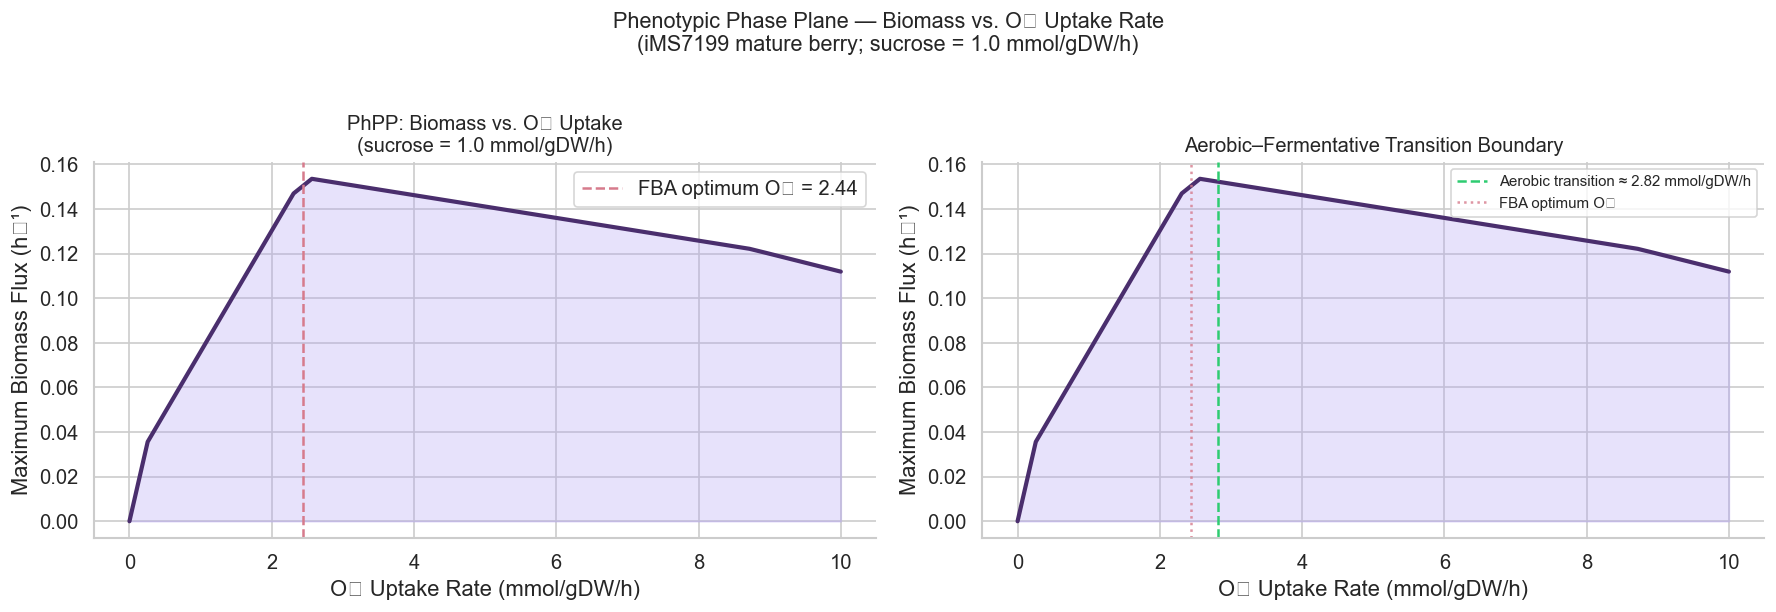

Aerobic–fermentative transition at O₂ ≈ 2.821 mmol/gDW/h
FBA-optimum O₂ = 2.440 mmol/gDW/h (→ well within aerobic regime)


In [32]:
if O2_RXN and env is not None and not env.empty:
    fig, axes = plt.subplots(1, 2, figsize = (15, 5))

    x_o2 = env[o2_col].abs()
    y_mu = env[mu_col]

    sort_idx = np.argsort(x_o2.values)
    x_o2     = x_o2.iloc[sort_idx]
    y_mu     = y_mu.iloc[sort_idx]

    # Left
    axes[0].fill_between(x_o2, 0, y_mu, color = '#B19FF4', alpha = 0.3)
    axes[0].plot(x_o2, y_mu, color = '#4A2E6D', linewidth = 2.5)
    axes[0].axvline(O2_BASELINE, 
                    color     = '#D67B8C', 
                    linestyle = '--', 
                    linewidth = 1.5,
                    label     = f'FBA optimum O₂ = {O2_BASELINE:.2f}')
    axes[0].set_xlabel('O₂ Uptake Rate (mmol/gDW/h)')
    axes[0].set_ylabel('Maximum Biomass Flux (h⁻¹)')
    axes[0].set_title('PhPP: Biomass vs. O₂ Uptake\n'
                      '(sucrose = 1.0 mmol/gDW/h)',
                      fontsize = 12)
    axes[0].legend()

    # Right
    x_arr = x_o2.values
    y_arr = y_mu.values
    valid = ~(np.isnan(x_arr) | np.isnan(y_arr))
    x_v, y_v = x_arr[valid], y_arr[valid]

    if len(x_v) > 2:
        slopes = np.gradient(y_v, x_v)
        max_slope = slopes.max()
        sat_idx = np.where(slopes < 0.05 * max_slope)[0]
        o2_transition = float(x_v[sat_idx[0]]) if len(sat_idx) > 0 else None
    else:
        o2_transition = None

    axes[1].fill_between(x_o2, 0, y_mu, color = '#B19FF4', alpha = 0.3)
    axes[1].plot(x_o2, y_mu, color = '#4A2E6D', linewidth = 2.5)
    if o2_transition is not None:
        axes[1].axvline(o2_transition, 
                        color     = '#2ecc71', 
                        linestyle = '--', 
                        lw        = 1.5,
                        label     = f'Aerobic transition ≈ {o2_transition:.2f} mmol/gDW/h')
    axes[1].axvline(O2_BASELINE, 
                    color     = '#D67B8C', 
                    linestyle = ':', 
                    lw        = 1.5, 
                    alpha     = 0.8,
                    label     = f'FBA optimum O₂')
    axes[1].set_xlabel('O₂ Uptake Rate (mmol/gDW/h)')
    axes[1].set_ylabel('Maximum Biomass Flux (h⁻¹)')
    axes[1].set_title('Aerobic–Fermentative Transition Boundary', fontsize = 12)
    axes[1].legend(fontsize = 9)

    plt.suptitle('Phenotypic Phase Plane — Biomass vs. O₂ Uptake Rate\n'
                 '(iMS7199 mature berry; sucrose = 1.0 mmol/gDW/h)',
                 fontsize = 13, y = 1.02)
    plt.tight_layout()
    # plt.savefig('fig9_phenotypic_phase_plane.png', dpi = 150, bbox_inches = 'tight')
    plt.show()

    if o2_transition is not None:
        print(f'Aerobic–fermentative transition at O₂ ≈ {o2_transition:.3f} mmol/gDW/h')
        print(f'FBA-optimum O₂ = {O2_BASELINE:.3f} mmol/gDW/h (→ well within aerobic regime)')
else:
    print('PhPP not computed (O2_RXN unavailable or env is None). Skipping plot.')
    o2_transition = None


## 10. Reaction IDs Curation

Reactions have IDs beginning with digits or symbols (--/+-) that are invalid as LP variable names. Bounds are effectively preserved (lower_bound = $0$ maintained by LP default).

$214$ reactions were renamed with prefix `R_` to resolve Gurobi LP variable name conflicts. All reactions were irreversible [$0, 100000$]; bounds and growth rate are unaffected.

In [33]:
bad_ids = [r.id for r in berry_model.reactions 
           if r.id[0] in ('-', '+') or r.id[0].isdigit()]
print(f'Reactions with problematic IDs: {len(bad_ids)}')
for rid in bad_ids[:10]:
    print(f'  {rid}')

default_bounds = (-1000.0, 1000.0)
affected = []
for rid in bad_ids:
    rxn = berry_model.reactions.get_by_id(rid)
    if (rxn.lower_bound, rxn.upper_bound) != default_bounds:
        affected.append({'ID': rid, 'LB': rxn.lower_bound, 'UB': rxn.upper_bound})

print(f'Reactions with non-default bounds among problematic IDs: {len(affected)}')
for r in affected[:10]:
    print(f"  {r['ID']:<50} [{r['LB']}, {r['UB']}]") 

renamed = []
for rxn in berry_model.reactions:
    if rxn.id[0].isdigit() or rxn.id[:2] in ('--', '+-'):
        old_id = rxn.id
        rxn.id = 'R_' + rxn.id.lstrip('-+')
        renamed.append((old_id, rxn.id))
        
# Update BIOMASS_RXN_VV if affected (check)
BIOMASS_RXN_VV = 'e-Biomass_vvinif2023_berry_mature__cyto'
print(berry_model.reactions.get_by_id(BIOMASS_RXN_VV))
mu_check = berry_model.optimize().objective_value
print(f'μ after renaming: {mu_check:.4f} h⁻¹')
print(f'Reactions renamed: {len(renamed)}')

assert abs(mu_check - 0.1541) < 1e-3, 'μ changed after renaming.'

Reactions with problematic IDs: 214
  3-OXOACYL-ACP-SYNTH-BASE-RXN__chlo
  1.10.2.2-RXN__mito
  4-COUMARATE--COA-LIGASE-RXN__pero
  1.14.11.20-RXN__cyto
  6PGLUCONOLACT-RXN__chlo
  6PGLUCONOLACT-RXN__cyto
  --MENTHOL-DEHYDROGENASE-RXN__cyto
  3.2.1.8-RXN__extr
  1.1.1.285-RXN__cyto
  3.1.3.46-RXN__cyto
Reactions with non-default bounds among problematic IDs: 214
  3-OXOACYL-ACP-SYNTH-BASE-RXN__chlo                 [0.0, 100000.0]
  1.10.2.2-RXN__mito                                 [0.0, 100000.0]
  4-COUMARATE--COA-LIGASE-RXN__pero                  [0.0, 100000.0]
  1.14.11.20-RXN__cyto                               [0.0, 100000.0]
  6PGLUCONOLACT-RXN__chlo                            [0.0, 100000.0]
  6PGLUCONOLACT-RXN__cyto                            [0.0, 100000.0]
  --MENTHOL-DEHYDROGENASE-RXN__cyto                  [0.0, 100000.0]
  3.2.1.8-RXN__extr                                  [0.0, 100000.0]
  1.1.1.285-RXN__cyto                                [0.0, 100000.0]
  3.1.3.46-RXN

## 11. Model Export
Export the curated model in SBML format (`VvM_mature_curated.xml`) and perform a round-trip validation to ensure structural and functional consistency. FBA was re-run after re-import, and growth rate consistency was confirmed.

In [34]:
final_sol = berry_model.optimize()
assert final_sol.status == 'optimal', 'Curated model is infeasible.'
print(f'Curated model status : {final_sol.status}')
print(f'Biomass flux (μ)     : {final_sol.objective_value:.4f} h⁻¹')

Curated model status : optimal
Biomass flux (μ)     : 0.1541 h⁻¹


In [35]:
EXPORT_PATH = 'VvM_mature_curated.xml'
write_sbml_model(berry_model, EXPORT_PATH)
print(f'Exported: {EXPORT_PATH}  ({os.path.getsize(EXPORT_PATH)/1024:.1f} kB)')

_rt_model = read_sbml_model(EXPORT_PATH)
_rt_sol   = _rt_model.optimize()

_rt_renamed   = sum(1 for r in _rt_model.reactions  if r.id.startswith('R_'))
_orig_renamed = sum(1 for r in berry_model.reactions if r.id.startswith('R_'))

assert _rt_sol.status == 'optimal',                                      'Round-trip model infeasible.'
assert abs(_rt_sol.objective_value - final_sol.objective_value) < 1e-6,  'Round-trip μ mismatch.'
assert 'e' in _rt_model.compartments,                                    'Extracellular compartment missing.'
assert len(_rt_model.reactions)   == len(berry_model.reactions),         'Reaction count mismatch.'
assert len(_rt_model.metabolites) == len(berry_model.metabolites),       'Metabolite count mismatch.'
assert _rt_renamed == _orig_renamed,                                     'Renaming curation lost.'

print('Round-trip integrity check PASSED')
print(f'    μ          : {final_sol.objective_value:.4f} → {_rt_sol.objective_value:.4f}')
print(f'    Reactions  : {len(_rt_model.reactions)}')
print(f'    Metabolites: {len(_rt_model.metabolites)}')
print(f'    R_ renamed : {_rt_renamed} reactions preserved')

Exported: VvM_mature_curated.xml  (11999.8 kB)
Round-trip integrity check PASSED
    μ          : 0.1541 → 0.1541
    Reactions  : 4272
    Metabolites: 5143
    R_ renamed : 214 reactions preserved


## 12. Model Limitations

1. **Post-mitotic tissue:** The biomass objective is inherited from the original GEM and does not reflect a measured growth rate. It should be treated as a metabolic flux proxy, not a cell-division rate.
2. **Blocked reactions:** A significant fraction of reactions carries zero flux under any feasible condition, arising from developmentally silenced pathways consistent with the *post-veraison* stage. They do not indicate reconstruction errors.
3. **Absence of transcriptional regulation:** Constraint-based modelling cannot capture infection-induced transcriptional reprogramming. Integrating RNA-seq data via the iMAT or MADE frameworks would improve physiological realism.
4. **Single-cell assumption:** The GEM models average cellular behaviour; spatial heterogeneity within berry tissue during infection is not captured.
5. **LP-invalid reaction IDs (curated):** $214$ reactions were renamed with prefix `R_` to resolve Gurobi LP variable name conflicts. Bounds and growth rate are unaffected.
6. **Compartment remapping:** Original C001–C010 codes were remapped to semantic identifiers. `C009 → 'e'` is required for COBRApy boundary-reaction detection.
7. **Single mass balance error:** `RXN0-5184__chlo` carries a stoichiometric discrepancy of C: $−84$, H: $−140$, O: $−70$.
8. **Subsystem annotation errors:** Several reactions carry subsystem labels inherited from non-plant databases. These are legitimate plant reactions with incorrect pathway attribution. No functional impact on flux calculations.

## 13. References

* **iMS7199** (Sampaio, M., Rocha, M., & Dias, O., 2024)

Sampaio, M., Rocha, M., & Dias, O. (2024). iMS7199 – genome-scale metabolic
model of *Vitis vinifera* (Model ID MODEL2408120001). [Data set]. BioModels.
https://biomodels.org/MODEL2408120001